<a href="https://colab.research.google.com/github/Yzctra/240441100126_Mar-atus-Solecha-Citra-Nurul-Huda_Tugas-2/blob/main/Tugas_Deep_Learning_B1_B3_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Deep Learning — B.1 sampai B.3

## Perbandingan CNN Custom dan Mini-ResNet pada CIFAR-10

Notebook ini mengimplementasikan dua model CNN menggunakan **PyTorch** pada dataset **CIFAR-10**. Kedua model memakai dataset, jumlah epoch, batch size, optimizer, dan learning rate yang sama agar perbandingan adil.

**Model A** adalah CNN custom dengan tiga blok Conv–ReLU–MaxPooling. **Model B** adalah Mini-ResNet dari awal dengan residual/skip connection.

> Catatan: model mengembalikan logits, bukan Softmax, karena training menggunakan `CrossEntropyLoss`. Softmax hanya digunakan ketika menghitung probabilitas prediksi saat evaluasi.


## B.1 — Dataset dan Setup

CIFAR-10 terdiri atas gambar RGB berukuran 32×32 dari 10 kelas. Data training akan dibagi menjadi data train dan validation, sedangkan test set tetap digunakan hanya pada evaluasi akhir.


In [1]:
# Instalasi opsional: Colab biasanya sudah menyediakan torch dan torchvision.
# Jalankan cell ini hanya jika import pada cell berikut mengalami error.
# !pip -q install torch torchvision scikit-learn seaborn


In [2]:
import os
import random
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cpu


In [3]:
# Hyperparameter identik untuk Model A dan Model B
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 10
NUM_CLASSES = 10
VAL_RATIO = 0.10
NUM_WORKERS = 2

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Normalisasi standar CIFAR-10
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Dataset training dibuat dua kali agar train memakai augmentasi dan validation tidak memakai augmentasi.
full_train_aug = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)
full_train_eval = datasets.CIFAR10(
    root="./data", train=True, download=False, transform=eval_transform
)
test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=eval_transform
)

val_size = int(len(full_train_aug) * VAL_RATIO)
train_size = len(full_train_aug) - val_size
split_generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(full_train_aug), generator=split_generator).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = torch.utils.data.Subset(full_train_aug, train_indices)
val_dataset = torch.utils.data.Subset(full_train_eval, val_indices)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f"Train: {len(train_dataset):,} gambar")
print(f"Validation: {len(val_dataset):,} gambar")
print(f"Test: {len(test_dataset):,} gambar")


100%|██████████| 170M/170M [15:33<00:00, 183kB/s]


Train: 45,000 gambar
Validation: 5,000 gambar
Test: 10,000 gambar


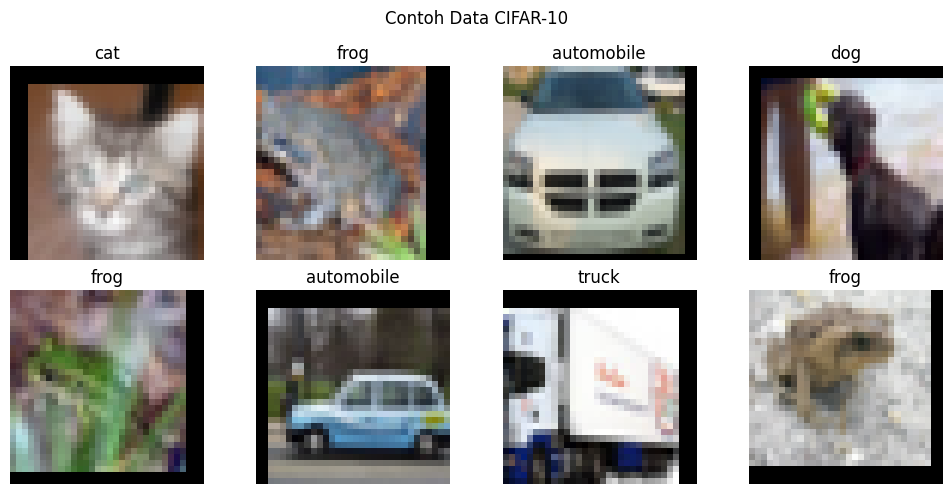

In [4]:
# Visualisasi beberapa contoh data
images, labels = next(iter(train_loader))
images_vis = images[:8].clone()
for channel in range(3):
    images_vis[:, channel] = images_vis[:, channel] * std[channel] + mean[channel]
images_vis = images_vis.permute(0, 2, 3, 1).numpy().clip(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), images_vis, labels[:8]):
    ax.imshow(image)
    ax.set_title(class_names[label.item()])
    ax.axis("off")
plt.suptitle("Contoh Data CIFAR-10")
plt.tight_layout()
plt.show()


## B.2 — Implementasi Model A dan Model B

Model B menggunakan residual block dengan rumus konseptual:

```text
y = ReLU(F(x) + shortcut(x))
```

Jika jumlah channel atau ukuran feature map berubah, `shortcut` menggunakan convolution 1×1 dengan stride yang sesuai. Dengan demikian, penjumlahan tensor tetap valid.


In [5]:
class CustomCNN(nn.Module):
    """Model A: CNN custom dengan minimal tiga blok Conv-ReLU-Pooling."""
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Blok 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Blok 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Blok 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity  # residual/skip connection
        return self.relu(out)


class MiniResNet(nn.Module):
    """Model B: Mini-ResNet dari awal untuk CIFAR-10."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32, stride=1),
            ResidualBlock(32, 32, stride=1),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64, stride=1),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=1),
        )
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)       # [B, 3, 32, 32] -> [B, 32, 32, 32]
        x = self.layer1(x)     # -> [B, 32, 32, 32]
        x = self.layer2(x)     # -> [B, 64, 16, 16]
        x = self.layer3(x)     # -> [B, 128, 8, 8]
        x = self.avg_pool(x)   # -> [B, 128, 1, 1]
        x = torch.flatten(x, 1)
        return self.classifier(x)  # logits [B, 10]


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_model_info(model, name):
    model = model.to(DEVICE)
    dummy = torch.randn(2, 3, 32, 32, device=DEVICE)
    with torch.no_grad():
        output = model(dummy)
    print(f"{name}")
    print(model)
    print(f"Trainable parameters: {count_parameters(model):,}")
    print(f"Output shape: {tuple(output.shape)}")
    print("-" * 80)

model_a_preview = CustomCNN(NUM_CLASSES)
model_b_preview = MiniResNet(NUM_CLASSES)
show_model_info(model_a_preview, "Model A — Custom CNN")
show_model_info(model_b_preview, "Model B — Mini-ResNet")


Model A — Custom CNN
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out

## Fungsi Training dan Evaluasi

Kedua model akan dilatih dengan konfigurasi identik. Validation set digunakan setelah setiap epoch untuk memantau generalisasi, sedangkan test set hanya digunakan satu kali pada evaluasi akhir.


In [6]:
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).sum().item()


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += accuracy_from_logits(logits, labels)
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, model_name, epochs=EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
    }
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    start_time = time.perf_counter()

    print(f"\nTraining {model_name}")
    print(f"Konfigurasi: epochs={epochs}, batch_size={BATCH_SIZE}, optimizer=Adam, lr={LEARNING_RATE}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
        )

    elapsed = time.perf_counter() - start_time
    model.load_state_dict(best_state)
    print(f"Waktu training {model_name}: {elapsed:.2f} detik ({elapsed / 60:.2f} menit)")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    return model, history, elapsed


## Training Model A dan Model B

Cell berikut adalah bagian utama eksperimen. Dengan GPU Colab, proses biasanya jauh lebih cepat. Jika CPU yang digunakan lambat, `EPOCHS` dapat dikurangi untuk uji coba, tetapi gunakan konfigurasi final yang sama untuk kedua model.


In [7]:
# Membuat dua model baru agar keduanya mulai dari kondisi awal yang terpisah.
model_a = CustomCNN(NUM_CLASSES).to(DEVICE)
model_b = MiniResNet(NUM_CLASSES).to(DEVICE)

model_a, history_a, time_a = train_model(model_a, "Model A — Custom CNN")
model_b, history_b, time_b = train_model(model_b, "Model B — Mini-ResNet")



Training Model A — Custom CNN
Konfigurasi: epochs=10, batch_size=128, optimizer=Adam, lr=0.001
Epoch 01/10 | train loss: 1.6048 | train acc: 0.4056 | val loss: 1.2572 | val acc: 0.5528
Epoch 02/10 | train loss: 1.2933 | train acc: 0.5330 | val loss: 1.1123 | val acc: 0.6054
Epoch 03/10 | train loss: 1.1620 | train acc: 0.5868 | val loss: 0.9690 | val acc: 0.6532
Epoch 04/10 | train loss: 1.0832 | train acc: 0.6171 | val loss: 0.8936 | val acc: 0.6912
Epoch 05/10 | train loss: 1.0206 | train acc: 0.6402 | val loss: 0.8720 | val acc: 0.6902
Epoch 06/10 | train loss: 0.9737 | train acc: 0.6592 | val loss: 0.8220 | val acc: 0.7088
Epoch 07/10 | train loss: 0.9335 | train acc: 0.6740 | val loss: 0.8023 | val acc: 0.7204
Epoch 08/10 | train loss: 0.9075 | train acc: 0.6858 | val loss: 0.8073 | val acc: 0.7134
Epoch 09/10 | train loss: 0.8757 | train acc: 0.6974 | val loss: 0.7338 | val acc: 0.7422
Epoch 10/10 | train loss: 0.8557 | train acc: 0.7051 | val loss: 0.7564 | val acc: 0.7300
Wakt

## B.3 — Kurva Loss dan Accuracy


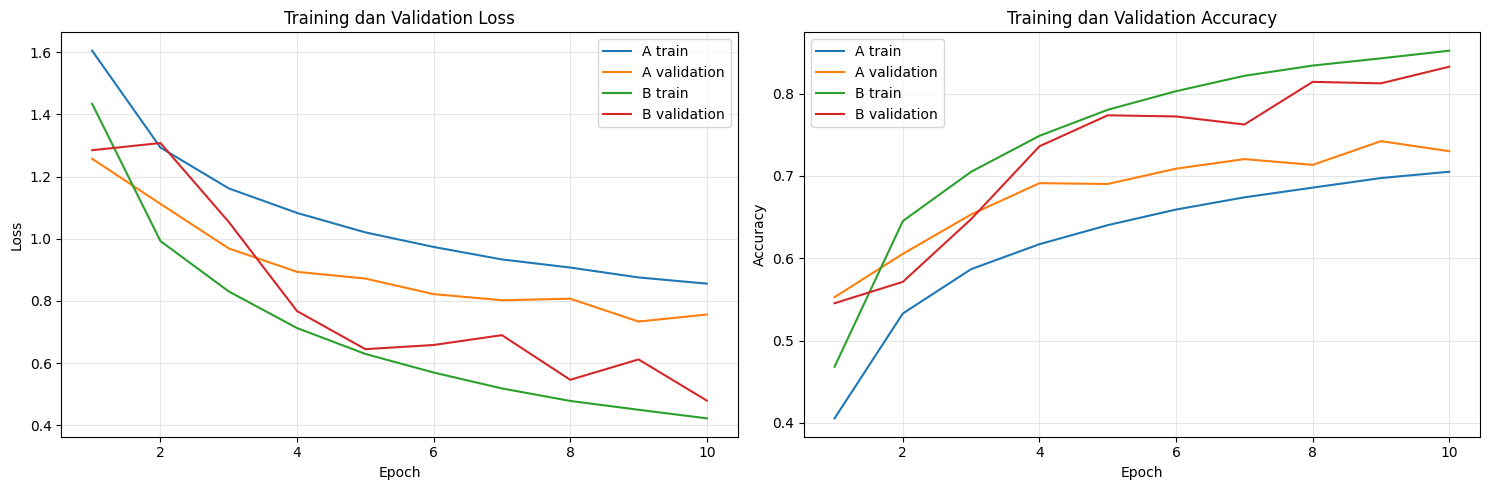

In [8]:
def plot_histories(history_a, history_b):
    epochs_range = range(1, len(history_a["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(epochs_range, history_a["train_loss"], label="A train")
    axes[0].plot(epochs_range, history_a["val_loss"], label="A validation")
    axes[0].plot(epochs_range, history_b["train_loss"], label="B train")
    axes[0].plot(epochs_range, history_b["val_loss"], label="B validation")
    axes[0].set_title("Training dan Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history_a["train_acc"], label="A train")
    axes[1].plot(epochs_range, history_a["val_acc"], label="A validation")
    axes[1].plot(epochs_range, history_b["train_acc"], label="B train")
    axes[1].plot(epochs_range, history_b["val_acc"], label="B validation")
    axes[1].set_title("Training dan Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_histories(history_a, history_b)


In [9]:
def evaluate_model(model, loader):
    model.eval()
    all_labels = []
    all_predictions = []
    total_loss = 0.0
    total_samples = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            predictions = logits.argmax(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    labels_np = np.array(all_labels)
    predictions_np = np.array(all_predictions)
    accuracy = (labels_np == predictions_np).mean()
    loss = total_loss / total_samples
    return loss, accuracy, labels_np, predictions_np


test_loss_a, test_acc_a, y_true_a, y_pred_a = evaluate_model(model_a, test_loader)
test_loss_b, test_acc_b, y_true_b, y_pred_b = evaluate_model(model_b, test_loader)

print(f"Model A — test loss: {test_loss_a:.4f}, test accuracy: {test_acc_a:.4f} ({test_acc_a * 100:.2f}%)")
print(f"Model B — test loss: {test_loss_b:.4f}, test accuracy: {test_acc_b:.4f} ({test_acc_b * 100:.2f}%)")


Model A — test loss: 0.7365, test accuracy: 0.7444 (74.44%)
Model B — test loss: 0.4967, test accuracy: 0.8297 (82.97%)


In [10]:
# Ringkasan jumlah parameter dan waktu training
summary = {
    "Model": ["Model A — Custom CNN", "Model B — Mini-ResNet"],
    "Trainable parameters": [count_parameters(model_a), count_parameters(model_b)],
    "Training time (seconds)": [time_a, time_b],
    "Training time (minutes)": [time_a / 60, time_b / 60],
    "Test accuracy (%)": [test_acc_a * 100, test_acc_b * 100],
}
summary_df = __import__("pandas").DataFrame(summary)
summary_df


,Model,Trainable parameters,Training time (seconds),Training time (minutes),Test accuracy (%)
0,Model A — Custom CNN,620810,1346.628692,22.443812,74.44
1,Model B — Mini-ResNet,696618,7991.085658,133.184761,82.97


### Confusion Matrix


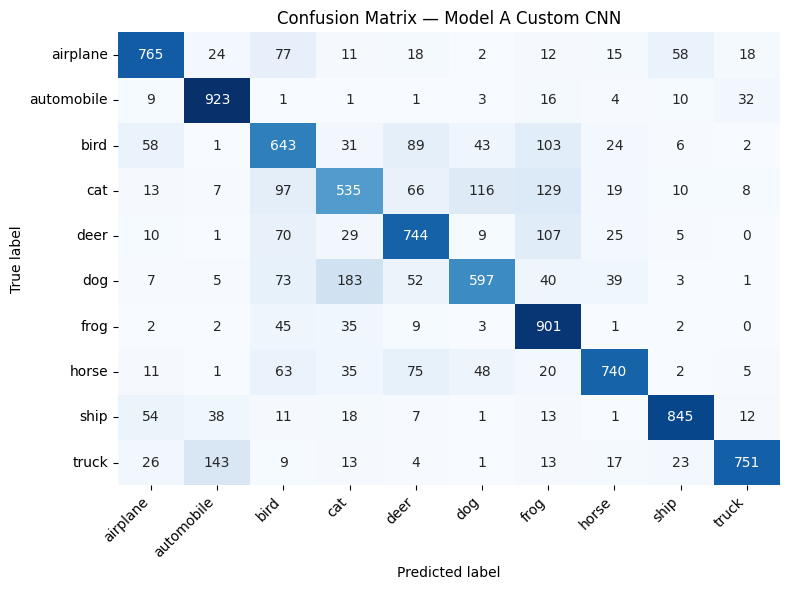

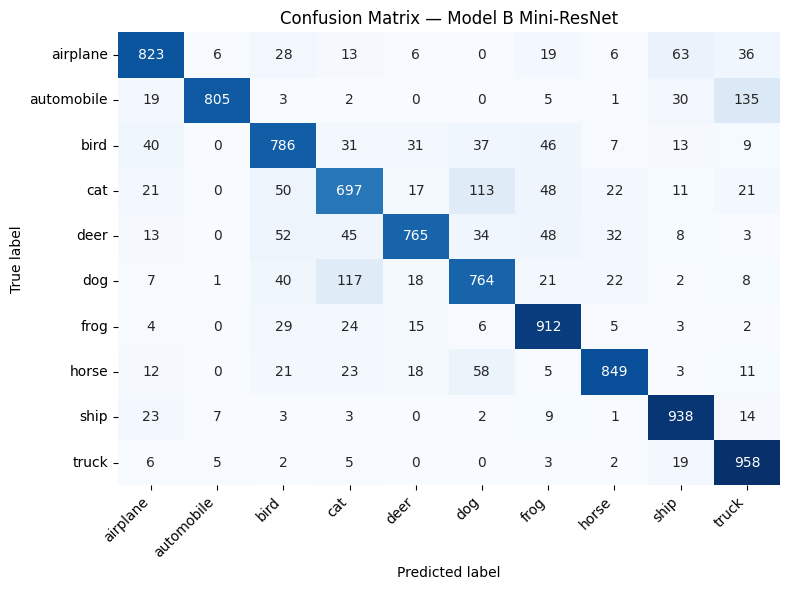

In [11]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true_a, y_pred_a, "Confusion Matrix — Model A Custom CNN")
plot_confusion_matrix(y_true_b, y_pred_b, "Confusion Matrix — Model B Mini-ResNet")


In [12]:
# Classification report tambahan untuk melihat precision, recall, dan F1-score per kelas.
print("Classification Report — Model A")
print(classification_report(y_true_a, y_pred_a, target_names=class_names, digits=4))

print("Classification Report — Model B")
print(classification_report(y_true_b, y_pred_b, target_names=class_names, digits=4))


Classification Report — Model A
              precision    recall  f1-score   support

    airplane     0.8010    0.7650    0.7826      1000
  automobile     0.8061    0.9230    0.8606      1000
        bird     0.5904    0.6430    0.6156      1000
         cat     0.6004    0.5350    0.5658      1000
        deer     0.6986    0.7440    0.7206      1000
         dog     0.7254    0.5970    0.6550      1000
        frog     0.6654    0.9010    0.7655      1000
       horse     0.8362    0.7400    0.7851      1000
        ship     0.8766    0.8450    0.8605      1000
       truck     0.9059    0.7510    0.8212      1000

    accuracy                         0.7444     10000
   macro avg     0.7506    0.7444    0.7433     10000
weighted avg     0.7506    0.7444    0.7433     10000

Classification Report — Model B
              precision    recall  f1-score   support

    airplane     0.8502    0.8230    0.8364      1000
  automobile     0.9769    0.8050    0.8827      1000
        bird  